In [1]:
import numpy as np
rng = np.random.default_rng(122807528840384100672342137672332424406)

from prod_fs import ProD

from matplotlib import rc
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

In [2]:
# Initializing grid and sample examples
X = np.array(
    [
        [
            1.00, 0.45, 0.823, 0.151,
            0.14, 0.00, 0.205, 0.382, 0.701
        ]
    ]
).T
y = np.array(
    (
        2, 2, 2, 2,
        1, 1, 1, 1, 1
    )
)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'


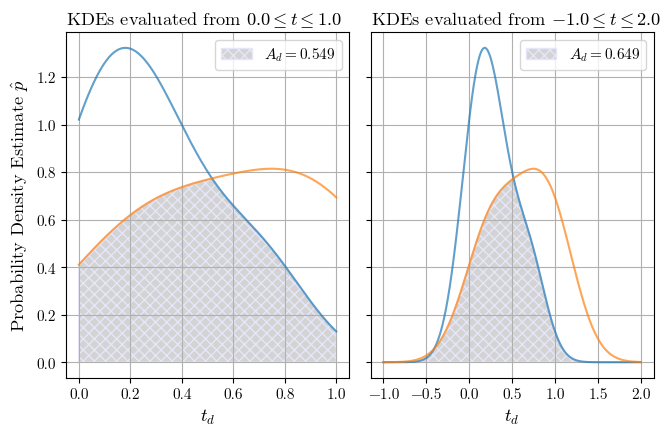

In [3]:
# Plot
plotlength = 9.0
fig, axs = plt.subplots(
    1, 2, sharey=True, figsize=(plotlength/1.33, plotlength/2)
)

prodRanker = ProD(k=2, lower_end=0.0, upper_end=1.0)
prodRanker.fit(X, y)
prodRanker.plot_overlapAreas(
    0, _combinations=None, legend="intersection",
    legend_fIndex='d', _ax=axs[0]
)
axs[0].grid(visible=True, which="major", axis="both")

prodRanker_p5 = ProD(k=2, lower_end=-1.0, upper_end=2.0)
prodRanker_p5.fit(X, y)
prodRanker_p5.plot_overlapAreas(
    0, _combinations=None, legend="intersection",
    legend_fIndex='d', _ax=axs[1]
)
axs[1].grid(visible=True, which="major", axis="both")

# Legends
axs[0].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize="medium")
axs[1].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize="medium")

# x-ticks
axs[0].set_xticks(np.arange(0.0, 1.2, 0.2))
axs[1].set_xticks(np.arange(-1.0, 2.5, 0.5))

# x-label
axs[0].set_xlabel(r"$t_d$")
axs[1].set_xlabel(r"$t_d$")

# y-label
axs[0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize="large")

# titles
axs[0].set_title(r"KDEs evaluated from $0.0 \leq t \leq 1.0$", loc="left")
axs[1].set_title(r"KDEs evaluated from $-1.0 \leq t \leq 2.0$", loc="left")

fig.tight_layout()